Cell 1 — Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


Cell 2 — Load Dataset


In [6]:
df = pd.read_csv("/content/car data.csv")

print("📁 Shape:", df.shape)
print("📌 Columns:", df.columns.tolist())
display(df.head())
display(df.tail())

📁 Shape: (301, 9)
📌 Columns: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


Cell 3 — Data Exploration

In [7]:
print("=" * 50)
print("📊 Basic Info")
print("=" * 50)
df.info()

print("\n📊 Statistical Summary:")
display(df.describe())

print("\n🔎 Missing Values:")
print(df.isnull().sum())

print("\n🔎 Duplicated Rows:", df.duplicated().sum())

print("\n📌 Unique Values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique values")

📊 Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

📊 Statistical Summary:


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000



🔎 Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

🔎 Duplicated Rows: 2

📌 Unique Values per column:
  Car_Name: 98 unique values
  Year: 16 unique values
  Selling_Price: 156 unique values
  Present_Price: 148 unique values
  Driven_kms: 206 unique values
  Fuel_Type: 3 unique values
  Selling_type: 2 unique values
  Transmission: 2 unique values
  Owner: 3 unique values


Cell 4 — Feature Engineering

In [8]:
df['Car_Age'] = 2024 - df['Year']

df['Price_Diff'] = df['Present_Price'] - df['Selling_Price']
df['Depreciation_Rate'] = (df['Price_Diff'] / df['Present_Price']) * 100

df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

print("✅ New Features Added:")
print(df[['Car_Age', 'Price_Diff', 'Depreciation_Rate']].head())
print("\n📐 Updated Shape:", df.shape)
display(df.head())

✅ New Features Added:
   Car_Age  Price_Diff  Depreciation_Rate
0       10        2.24          40.071556
1       11        4.79          50.209644
2        7        2.60          26.395939
3       13        1.30          31.325301
4       10        2.27          33.042213

📐 Updated Shape: (301, 10)


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Price_Diff,Depreciation_Rate
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10,2.24,40.071556
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11,4.79,50.209644
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7,2.60,26.395939
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13,1.30,31.325301
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10,2.27,33.042213


Cell 5 — Visualizations (EDA)


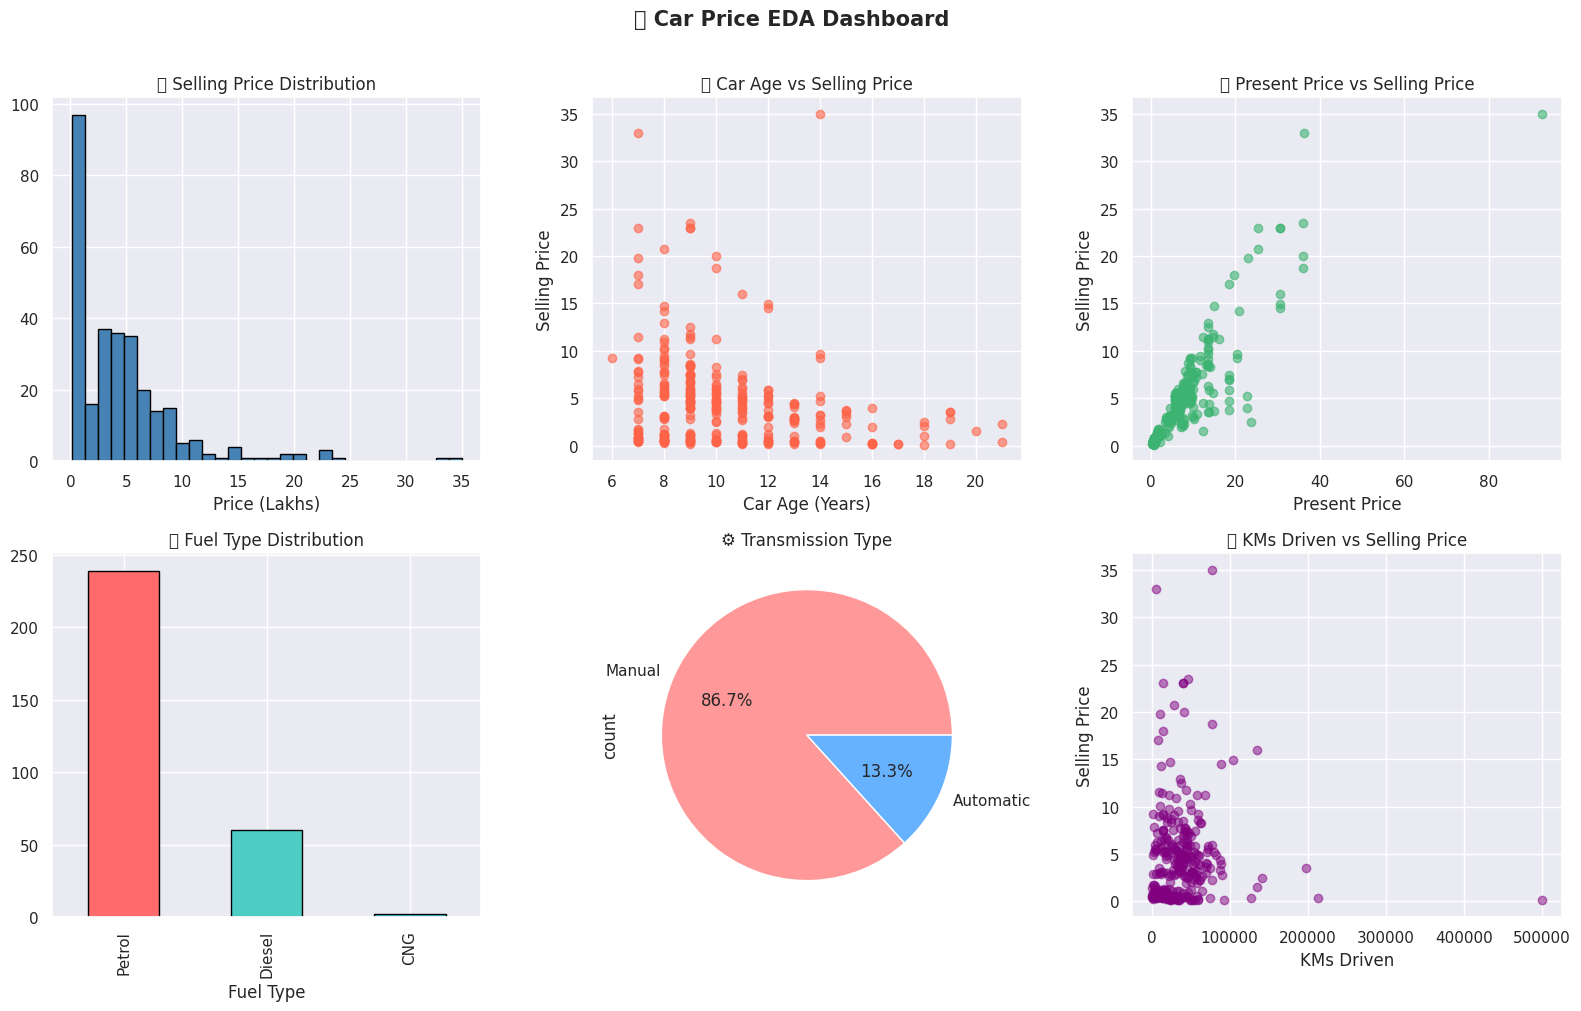

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Selling Price Distribution
axes[0,0].hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='black')
axes[0,0].set_title('💰 Selling Price Distribution')
axes[0,0].set_xlabel('Price (Lakhs)')

# 2. Car Age vs Selling Price
axes[0,1].scatter(df['Car_Age'], df['Selling_Price'], alpha=0.6, color='tomato')
axes[0,1].set_title('📅 Car Age vs Selling Price')
axes[0,1].set_xlabel('Car Age (Years)')
axes[0,1].set_ylabel('Selling Price')

# 3. Present Price vs Selling Price
axes[0,2].scatter(df['Present_Price'], df['Selling_Price'], alpha=0.6, color='mediumseagreen')
axes[0,2].set_title('💵 Present Price vs Selling Price')
axes[0,2].set_xlabel('Present Price')
axes[0,2].set_ylabel('Selling Price')

# 4. Fuel Type Count
df['Fuel_Type'].value_counts().plot(kind='bar', ax=axes[1,0], color=['#FF6B6B','#4ECDC4','#45B7D1'], edgecolor='black')
axes[1,0].set_title('⛽ Fuel Type Distribution')
axes[1,0].set_xlabel('Fuel Type')

# 5. Transmission Count
df['Transmission'].value_counts().plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%',
                                        colors=['#FF9999','#66B2FF'])
axes[1,1].set_title('⚙️ Transmission Type')

# 6. Driven KMs vs Selling Price
axes[1,2].scatter(df['Driven_kms'], df['Selling_Price'], alpha=0.5, color='purple')
axes[1,2].set_title('🛣️ KMs Driven vs Selling Price')
axes[1,2].set_xlabel('KMs Driven')
axes[1,2].set_ylabel('Selling Price')

plt.suptitle('🚗 Car Price EDA Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Cell 6 — Avg Price by Category

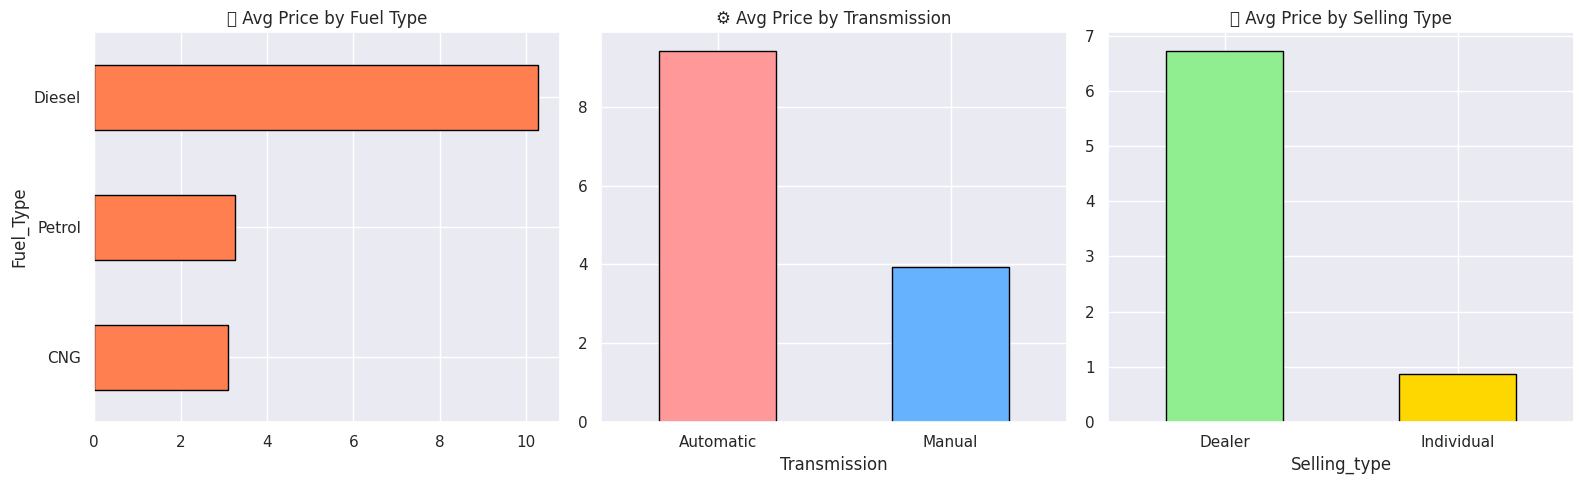

In [10]:


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By Fuel Type
df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('⛽ Avg Price by Fuel Type')

# By Transmission
df.groupby('Transmission')['Selling_Price'].mean().plot(
    kind='bar', ax=axes[1], color=['#FF9999','#66B2FF'], edgecolor='black')
axes[1].set_title('⚙️ Avg Price by Transmission')
axes[1].tick_params(rotation=0)

# By Selling Type
df.groupby('Selling_type')['Selling_Price'].mean().plot(
    kind='bar', ax=axes[2], color=['#90EE90','#FFD700'], edgecolor='black')
axes[2].set_title('🏪 Avg Price by Selling Type')
axes[2].tick_params(rotation=0)

plt.tight_layout()
plt.show()

Cell 7 — Correlation Heatmap

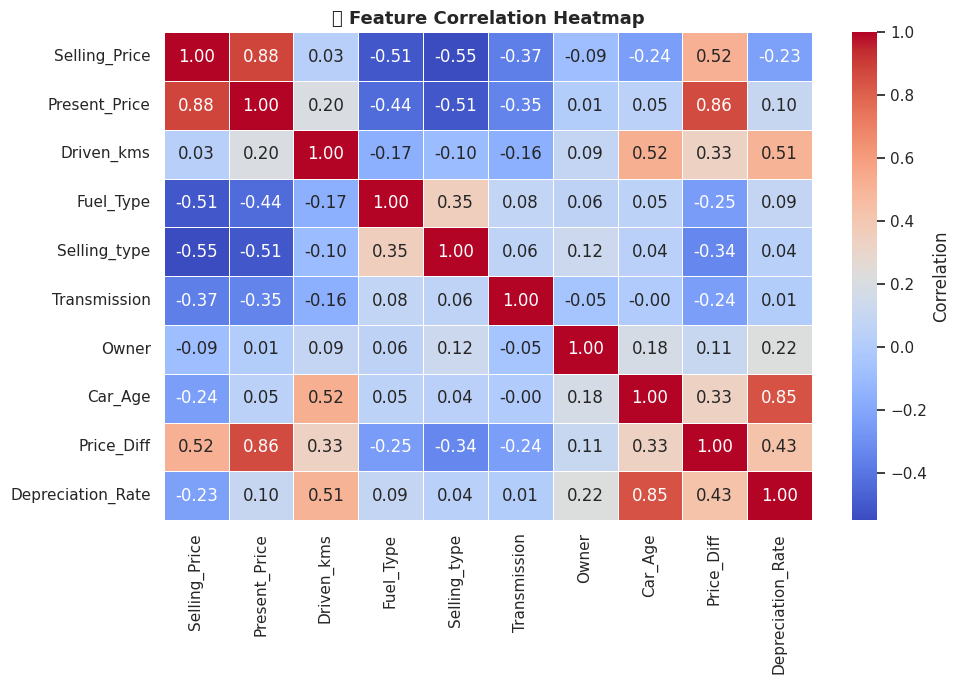

In [11]:
# Encode for correlation
df_corr = df.copy()
le = LabelEncoder()
for col in ['Fuel_Type', 'Selling_type', 'Transmission']:
    df_corr[col] = le.fit_transform(df_corr[col])

plt.figure(figsize=(10, 7))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            cbar_kws={'label': 'Correlation'})
plt.title('🔗 Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Cell 8 — Encode & Prepare Data

In [12]:
df_model = df.copy()

# Label Encoding
le = LabelEncoder()
for col in ['Fuel_Type', 'Selling_type', 'Transmission']:
    df_model[col] = le.fit_transform(df_model[col])

# Features & Target
X = df_model.drop(['Selling_Price', 'Price_Diff', 'Depreciation_Rate'], axis=1)
y = df_model['Selling_Price']

print("✅ Features used:", X.columns.tolist())
print("📐 X shape:", X.shape)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\n📊 Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

✅ Features used: ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']
📐 X shape: (301, 7)

📊 Train size: 240 | Test size: 61


Cell 9 — Train 3 Models

In [13]:
models = {
    'Linear Regression'      : LinearRegression(),
    'Random Forest'          : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'      : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'model': model, 'y_pred': y_pred}

    print(f"🔹 {name}")
    print(f"   MAE : {mae:.3f} | RMSE: {rmse:.3f} | R² : {r2:.4f}")
    print()

🔹 Linear Regression
   MAE : 1.222 | RMSE: 1.879 | R² : 0.8467

🔹 Random Forest
   MAE : 0.639 | RMSE: 0.969 | R² : 0.9593

🔹 Gradient Boosting
   MAE : 0.556 | RMSE: 0.891 | R² : 0.9656



Cell 10 — Compare Models

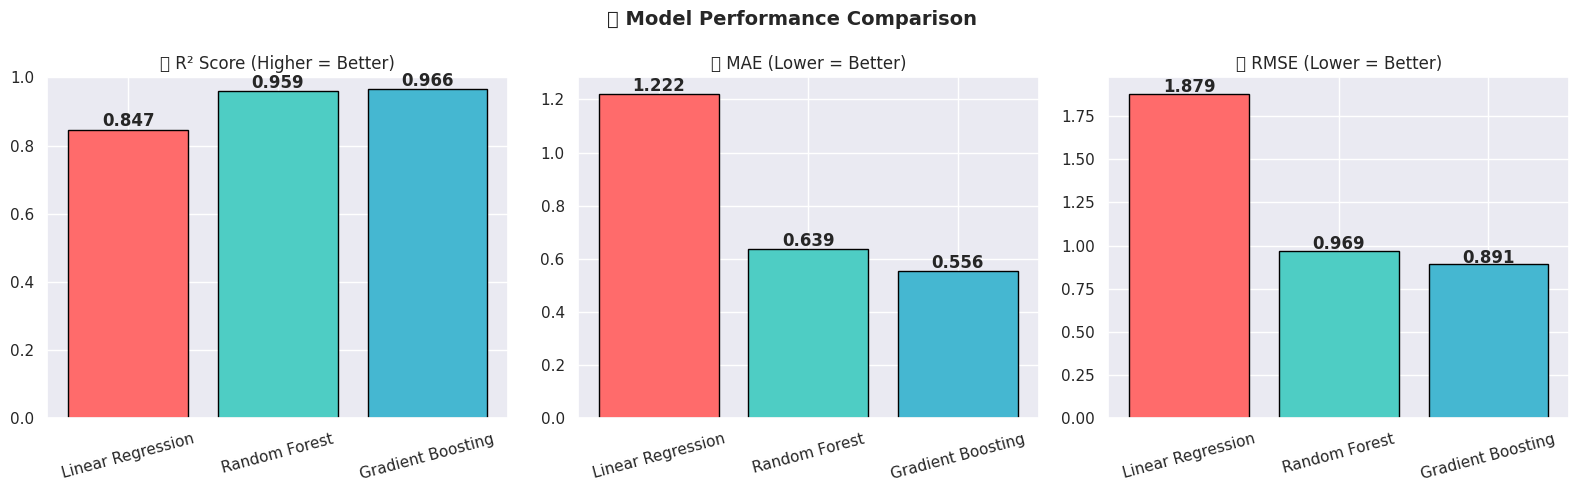

In [14]:
model_names = list(results.keys())
r2_scores   = [results[m]['R2']   for m in model_names]
mae_scores  = [results[m]['MAE']  for m in model_names]
rmse_scores = [results[m]['RMSE'] for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

axes[0].bar(model_names, r2_scores, color=colors, edgecolor='black')
axes[0].set_title('📈 R² Score (Higher = Better)')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(model_names, mae_scores, color=colors, edgecolor='black')
axes[1].set_title('📉 MAE (Lower = Better)')
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[2].bar(model_names, rmse_scores, color=colors, edgecolor='black')
axes[2].set_title('📉 RMSE (Lower = Better)')
for i, v in enumerate(rmse_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('🤖 Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Cell 11 — Actual vs Predicted

🏆 Best Model: Gradient Boosting (R² = 0.9656)


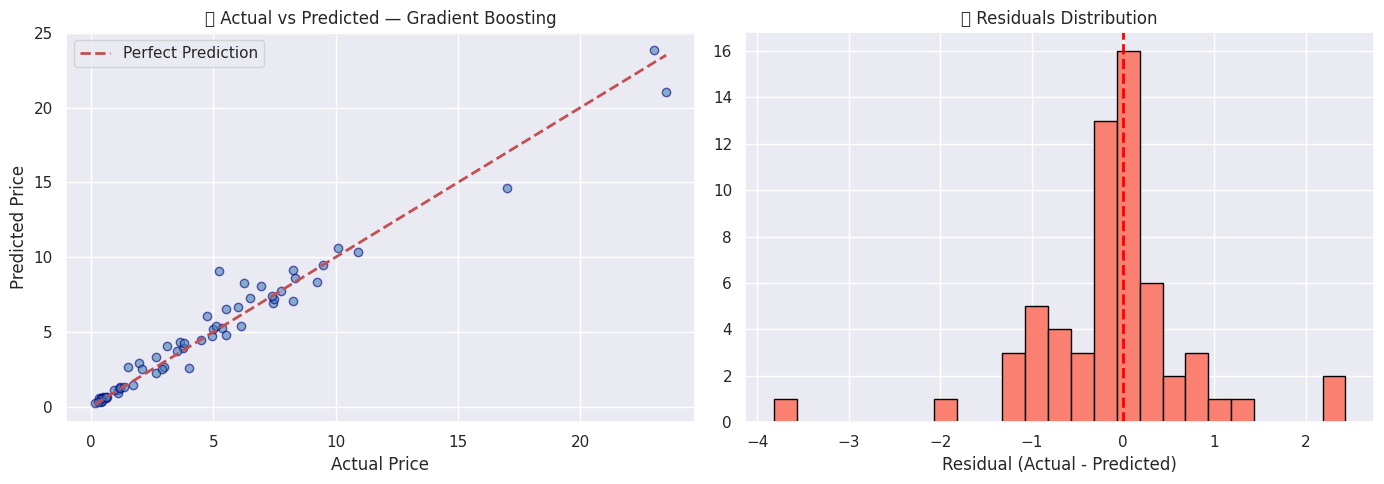

In [15]:
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_pred       = results[best_model_name]['y_pred']

print(f"🏆 Best Model: {best_model_name} (R² = {results[best_model_name]['R2']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, best_pred, alpha=0.6, color='steelblue', edgecolors='navy')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'✅ Actual vs Predicted — {best_model_name}')
axes[0].legend()

# Residuals
residuals = y_test.values - best_pred
axes[1].hist(residuals, bins=25, color='salmon', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('📊 Residuals Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

Cell 12 — Feature Importance

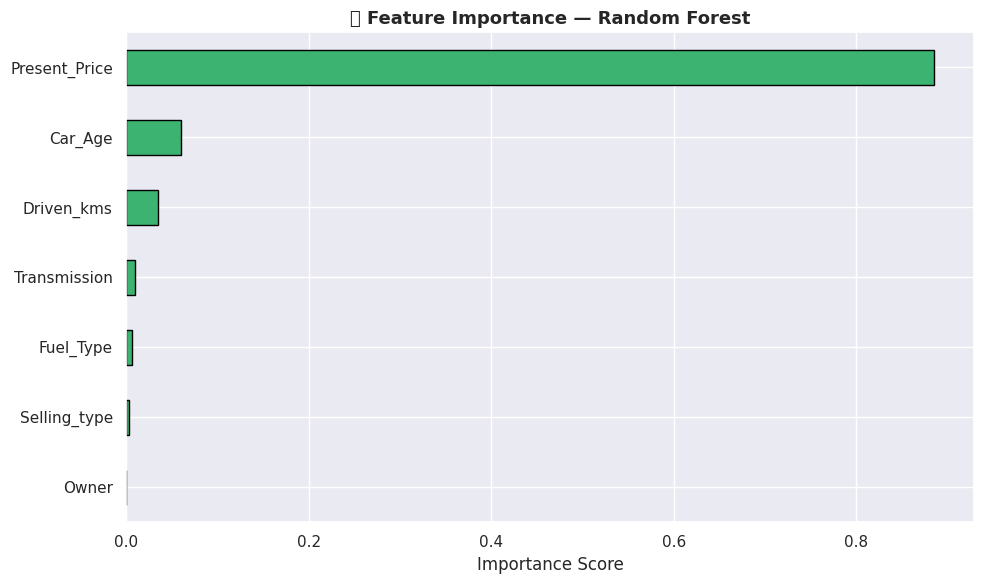


📌 Feature Rankings:
Present_Price    0.884504
Car_Age          0.060462
Driven_kms       0.034973
Transmission     0.009999
Fuel_Type        0.006507
Selling_type     0.003489
Owner            0.000067


In [16]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('🔑 Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n📌 Feature Rankings:")
print(importances.sort_values(ascending=False).to_string())

Cell 13 — Predict New Car Price

In [17]:
new_car = pd.DataFrame({
    'Present_Price' : [8.5],
    'Driven_kms'    : [30000],
    'Fuel_Type'     : [1],
    'Selling_type'  : [0],
    'Transmission'  : [0],
    'Owner'         : [0],
    'Car_Age'       : [5]
})

best_model = results[best_model_name]['model']
predicted_price = best_model.predict(new_car)[0]

print(f"🚗 Predicted Selling Price: ₹ {predicted_price:.2f} Lakhs")
print(f"   (Using: {best_model_name})")

🚗 Predicted Selling Price: ₹ 7.54 Lakhs
   (Using: Gradient Boosting)


Cell 14 — Final Summary

In [19]:
print("=" * 60)
print("     🚗 CAR PRICE PREDICTION — FINAL SUMMARY")
print("=" * 60)
print(f"""
📁 DATASET:
   • Total Records     : {len(df)} cars
   • Features Used     : {X.shape[1]}
   • Target            : Selling Price (Lakhs ₹)

📊 DATA INSIGHTS:
   • Avg Selling Price  : ₹ {df['Selling_Price'].mean():.2f} Lakhs
   • Max Selling Price  : ₹ {df['Selling_Price'].max():.2f} Lakhs
   • Min Selling Price  : ₹ {df['Selling_Price'].min():.2f} Lakhs
   • Most Common Fuel   : {df['Fuel_Type'].mode()[0]}

🤖 MODEL RESULTS:""")

for name in results:
    r  = results[name]['R2']
    m  = results[name]['MAE']
    rm = results[name]['RMSE']
    print(f"   {'🏆' if name==best_model_name else '  '} {name:<25} R²={r:.4f} | MAE={m:.3f} | RMSE={rm:.3f}")

print(f"""
🏆 BEST MODEL: {best_model_name}
   R² Score: {results[best_model_name]['R2']:.4f} ({results[best_model_name]['R2']*100:.1f}% variance explained)

🔑 KEY FINDINGS:
   1. Present_Price is the strongest predictor of Selling Price
   2. Car Age negatively impacts price (older = cheaper)
   3. Diesel cars sell at higher prices than Petrol
   4. Automatic transmission commands a price premium
   5. High KMs driven reduces resale value significantly
""")
print("=" * 60)

     🚗 CAR PRICE PREDICTION — FINAL SUMMARY

📁 DATASET:
   • Total Records     : 301 cars
   • Features Used     : 7
   • Target            : Selling Price (Lakhs ₹)

📊 DATA INSIGHTS:
   • Avg Selling Price  : ₹ 4.66 Lakhs
   • Max Selling Price  : ₹ 35.00 Lakhs
   • Min Selling Price  : ₹ 0.10 Lakhs
   • Most Common Fuel   : Petrol

🤖 MODEL RESULTS:
      Linear Regression         R²=0.8467 | MAE=1.222 | RMSE=1.879
      Random Forest             R²=0.9593 | MAE=0.639 | RMSE=0.969
   🏆 Gradient Boosting         R²=0.9656 | MAE=0.556 | RMSE=0.891

🏆 BEST MODEL: Gradient Boosting
   R² Score: 0.9656 (96.6% variance explained)

🔑 KEY FINDINGS:
   1. Present_Price is the strongest predictor of Selling Price
   2. Car Age negatively impacts price (older = cheaper)
   3. Diesel cars sell at higher prices than Petrol
   4. Automatic transmission commands a price premium
   5. High KMs driven reduces resale value significantly

